In [1]:
import sys, io, warnings, time, json
from pathlib import Path
from contextlib import redirect_stdout
from itertools import product, combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

from run_simulation import run_simulation
from utils.metrics import (
    compute_metrics, build_result_row, save_result_row,
    aggregate_config, load_all_aggregated,
)

# ── Paden ──────────────────────────────────────────────────────────────────
RESULTS_DIR = Path.cwd().parent / "results" / "Timing_Strategies_25/05"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Results dir: {RESULTS_DIR.resolve()}")

Results dir: /Users/ddw/Desktop/Rescheduling/results/Timing_Strategies_25/05


In [2]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║                    BATCH-INSTELLINGEN (AANPASSEN!)                  ║
# ╚══════════════════════════════════════════════════════════════════════╝
TARGET_SEEDS = 50          # Vul elke config tot dit aantal seeds (0..TARGET_SEEDS-1)

# ── Welke trigger-types meenemen? ──────────────────────────────────────────
INCLUDE_BASELINE     = True   # FCFS only — 1 config (periodic_freq=100_000)
INCLUDE_PERIODIC     = True   # 7 configs (verschillende periodic_freq)
INCLUDE_EVENT_DRIVEN = True    # 39 configs (5 ed_rf × cf × 3 tc)
INCLUDE_HYBRID       = True    # 66 configs (22 (ed_rf,cf,prf) × 3 tc)

# ── Welke priorities meenemen? ─────────────────────────────────────────────
INCLUDE_NO_PRIORITY = True
INCLUDE_STATIC      = True
INCLUDE_DYNAMIC     = True

# ── Per-seed sim-output (df met trein-niveau detail) als parquet bewaren? ──
# True  = parquets per seed komen in cfg_dir/<auto_naam>/seed_X.parquet
#         (handig voor latere diepteanalyses zonder reruns)
# False = alleen raw_runs.csv met geaggregeerde metrics (lichter op disk)
SAVE_PER_SEED_PARQUET = True

# ── Vaste simulatieparameters (overgenomen van Calibrate_Timing) ───────────
N_FREIGHT          = 182      # ≈15% freight share
FREIGHT_PCT        = 0.15
GAMMA              = 120      # s — dynamic_threshold (uit calibrate_gamma)
MC_DELAY_PER_TRAIN = 120      # s — Monte-Carlo delay per actieve trein
SOLVER_TIMEOUT     = 60       # s
PHASE              = 1

# ── Priority-gewichten (overgenomen van Fase1) ─────────────────────────────
WEIGHT_PASS_PRIO = 1     # weight_passenger als priority actief (static/dynamic)
WEIGHT_FREIGHT_PRIO = 1  # weight_freight als priority actief
UPGRADE_WEIGHT      = 1     # extra penalty als delay >= gamma (alleen bij dynamic)
subtype_weights = {
      "EURST":   10,   # Internationaal HSL — slot agreements, hoge boetes
      "ICE":     10,   # Idem internationale HSL
      "INT":      5,   # Internationaal (regulier)
      "IC":       3,   # Domestic backbone
      "S":        3,   # Veel pendelaars in piek — Brusselse corridor!
      "L":        2,   # Lokaal
      "freight":  1,   # Basislijn
      }

print(f"TARGET_SEEDS     = {TARGET_SEEDS}")
print(f"Triggers actief  : baseline={INCLUDE_BASELINE}, periodic={INCLUDE_PERIODIC}, "
      f"event_driven={INCLUDE_EVENT_DRIVEN}, hybrid={INCLUDE_HYBRID}")
print(f"Priorities actief: no_priority={INCLUDE_NO_PRIORITY}, "
      f"static={INCLUDE_STATIC}, dynamic={INCLUDE_DYNAMIC}")
print(f"Save parquets    = {SAVE_PER_SEED_PARQUET}")
print(f"GAMMA            = {GAMMA}s  |  MC_DELAY = {MC_DELAY_PER_TRAIN}s")
configs = []
# -----------------------------------------------------------------------
# Baseline — FCFS only, solver never fires
# -----------------------------------------------------------------------
configs.append({
    'trigger_strategy':     'periodic',
    'periodic_freq':        100_000,
    'event_driven_freq':    900,
    'controller_freq':      300,
    'threshold_confidence': 0.6,
})
# -----------------------------------------------------------------------
# Periodic — 7 values
# -----------------------------------------------------------------------
for prf in [450, 900, 1800, 3600]:
    configs.append({
        'trigger_strategy':     'periodic',
        'periodic_freq':        prf,
        'event_driven_freq':    900,
        'controller_freq':      300,
        'threshold_confidence': 0.6,
    })
# -----------------------------------------------------------------------
# # Event-Driven — inclusief nieuwe edf=600 configs
# # -----------------------------------------------------------------------
ed_rf_cf_map = {
    600:  [300, 600],
    900:  [450, 900],
    1800: [450, 900, 1800],
    3600: [900, 1800, 3600],
    5400: [1800, 3600, 5400],
}
tc_values = [0.4, 0.8]
for ed_rf, cf_list in ed_rf_cf_map.items():
    for cf in cf_list:
        for tc in tc_values:
            configs.append({
                'trigger_strategy':     'event_driven',
                'event_driven_freq':    ed_rf,
                'controller_freq':      cf,
                'threshold_confidence': tc,
                'periodic_freq':        100_000,
            })
# -----------------------------------------------------------------------
# Hybrid — bestaande + nieuwe met ed_rf=900 en ed_rf=600
# -----------------------------------------------------------------------
hybrid_combos = [
    # --- bestaand ---
    (1800, 900,  3600), 
    (1800, 900,  5400), 
    (1800, 900,  7200), 
    (3600, 900,  5400), (3600, 1800, 5400), 
    (3600, 900,  7200), (3600, 1800, 7200), 
    (5400, 900,  7200), (5400, 1800, 7200),
    # --- nieuw: ed_rf=900 ---
    (900, 450, 1800), (900, 450, 3600),
]
for ed_rf, cf, prf in hybrid_combos:
    for tc in tc_values:
        configs.append({
            'trigger_strategy':     'hybrid',
            'event_driven_freq':    ed_rf,
            'controller_freq':      cf,
            'periodic_freq':        prf,
            'threshold_confidence': tc,
        })
# -----------------------------------------------------------------------
# Tellen
# -----------------------------------------------------------------------
n_baseline     = sum(1 for c in configs if c['trigger_strategy'] == 'periodic' and c['periodic_freq'] == 100_000)
n_periodic     = sum(1 for c in configs if c['trigger_strategy'] == 'periodic' and c['periodic_freq'] != 100_000)
n_event_driven = sum(1 for c in configs if c['trigger_strategy'] == 'event_driven')
n_hybrid       = sum(1 for c in configs if c['trigger_strategy'] == 'hybrid')
print(f'Total configurations: {len(configs)}')
print(f'  Baseline:     {n_baseline}')
print(f'  Periodic:     {n_periodic}')
print(f'  Event-Driven: {n_event_driven}  (+6 nieuw: edf=600 × 2 cf × 3 tc)')
print(f'  Hybrid:       {n_hybrid}  (+12 nieuw: ed_rf=900/600 × 4 combos × 3 tc)')
print(f'\nTotal runs: {len(configs)} x {TARGET_SEEDS} = {len(configs) * TARGET_SEEDS}')
# ── Priority-configuraties (uit Fase1_Experiment.ipynb) ───────────────────
priority_configs = {}

if INCLUDE_NO_PRIORITY:
    priority_configs["no_priority"] = dict(
        objective_strategy = "static",
        weight_passenger   = 1,
        weight_freight     = 1,
        upgrade_weight     = UPGRADE_WEIGHT,
        dynamic_threshold  = GAMMA,
    )
# if INCLUDE_STATIC:
#     priority_configs["static"] = dict(
#         objective_strategy = "static",
#         weight_passenger   = WEIGHT_PASS_PRIO,
#         weight_freight     = WEIGHT_FREIGHT_PRIO,
#         upgrade_weight     = UPGRADE_WEIGHT,
#         subtype_weights = subtype_weights,
#         dynamic_threshold  = GAMMA,
#     )
# if INCLUDE_DYNAMIC:
#     priority_configs["dynamic"] = dict(
#         objective_strategy = "dynamic",
#         weight_passenger   = WEIGHT_PASS_PRIO,
#         weight_freight     = WEIGHT_FREIGHT_PRIO,
#         upgrade_weight     = UPGRADE_WEIGHT,
#         dynamic_threshold  = GAMMA,
#     )

PRIORITY_ORDER = [p for p in ["no_priority", "static", "dynamic"] if p in priority_configs]
TRIGGER_ORDER  = [t for t in ["periodic", "event_driven", "hybrid"]
                  if any(c["trigger_strategy"] == t for c in configs)]

print(f"Priorities: {PRIORITY_ORDER}")
print(f"Triggers:   {TRIGGER_ORDER}")

# ── Volledig grid: Cartesiaans product ────────────────────────────────────
CONFIGS = list(product(configs, PRIORITY_ORDER))

print(f"\nTotaal configs (timing × priority): {len(CONFIGS)}")
print(f"Totaal runs voor TARGET_SEEDS={TARGET_SEEDS}: {len(CONFIGS) * TARGET_SEEDS}")
def load_all_raw() -> pd.DataFrame:
    """Laadt alle raw_runs.csv bestanden uit RESULTS_DIR in één DataFrame."""
    frames = []
    for cfg_dir in sorted(RESULTS_DIR.iterdir()):
        if not cfg_dir.is_dir():
            continue
        csv_path = cfg_dir / "raw_runs.csv"
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            df["config"] = cfg_dir.name
            frames.append(df)
    if not frames:
        print("Geen resultaten gevonden.")
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


raw = load_all_raw()
print(f"Geladen: {len(raw)} rijen uit {raw['config'].nunique()} configs")

# Filter deadlocks uit voor performantie-analyses (maar bewaar voor overzicht)
if "deadlock" in raw.columns:
    n_deadlock = raw["deadlock"].fillna(False).astype(bool).sum()
    print(f"Deadlocks: {n_deadlock} runs (worden uitgesloten van metric-analyses)")
    raw_all = raw.copy()
    raw = raw[~raw["deadlock"].fillna(False).astype(bool)].copy()
else:
    raw_all = raw.copy()

# Canonieke ordering
raw["trigger"]  = pd.Categorical(raw["strategy_type"], categories=TRIGGER_ORDER, ordered=True)
raw["priority"] = pd.Categorical(raw["priority"],      categories=PRIORITY_ORDER, ordered=True)

print(f"\nNa filtering deadlocks: {len(raw)} rijen voor analyse")


TARGET_SEEDS     = 50
Triggers actief  : baseline=True, periodic=True, event_driven=True, hybrid=True
Priorities actief: no_priority=True, static=True, dynamic=True
Save parquets    = True
GAMMA            = 120s  |  MC_DELAY = 120s
Total configurations: 53
  Baseline:     1
  Periodic:     4
  Event-Driven: 26  (+6 nieuw: edf=600 × 2 cf × 3 tc)
  Hybrid:       22  (+12 nieuw: ed_rf=900/600 × 4 combos × 3 tc)

Total runs: 53 x 50 = 2650
Priorities: ['no_priority']
Triggers:   ['periodic', 'event_driven', 'hybrid']

Totaal configs (timing × priority): 53
Totaal runs voor TARGET_SEEDS=50: 2650
Geladen: 2650 rijen uit 53 configs
Deadlocks: 46 runs (worden uitgesloten van metric-analyses)

Na filtering deadlocks: 2604 rijen voor analyse


In [3]:
raw_all.columns

Index(['seed', 'phase', 'strategy_type', 'periodic_rf', 'event_driven_rf',
       'controller_freq', 'threshold_conf', 'priority', 'weight_passenger',
       'weight_freight', 'gamma', 'upgrade', 'w_IC', 'w_L', 'w_S', 'w_EURST',
       'w_ICE', 'w_INT', 'w_freight', 'objective', 'freight_pct',
       'mc_delay_per_train', 'solver_timeout', 'total_solve_time',
       'n_rescheduled', 'n_fcfs_fallback', 'n_skipped', 'infeasible_run',
       'deadlock', 'TED_passenger', 'TED_freight', 'TED_combined',
       'TAD_passenger', 'TAD_freight', 'TAD_combined', 'delay_ratio',
       'n_passenger', 'n_freight', 'TED_IC', 'TED_L', 'TED_S', 'TED_EURST',
       'TED_ICE', 'TED_INT', 'n_IC', 'n_L', 'n_S', 'n_EURST', 'n_ICE', 'n_INT',
       'n_unfinished_IC', 'n_unfinished_L', 'n_unfinished_S',
       'n_unfinished_EURST', 'n_unfinished_ICE', 'n_unfinished_INT',
       'n_unfinished_freight', 'n_unfinished_total', 'config'],
      dtype='str')

In [6]:
raw_periodic = raw_all[(raw_all["strategy_type"] == "periodic")]

In [7]:
raw_periodic.head()

,seed,phase,strategy_type,periodic_rf,event_driven_rf,controller_freq,threshold_conf,priority,weight_passenger,weight_freight,...,n_INT,n_unfinished_IC,n_unfinished_L,n_unfinished_S,n_unfinished_EURST,n_unfinished_ICE,n_unfinished_INT,n_unfinished_freight,n_unfinished_total,config
0,0,1,periodic,100000,900,300,0.6,no_priority,1,1,...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,baseline_no_priority
1,1,1,periodic,100000,900,300,0.6,no_priority,1,1,...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,baseline_no_priority
2,2,1,periodic,100000,900,300,0.6,no_priority,1,1,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,baseline_no_priority
3,3,1,periodic,100000,900,300,0.6,no_priority,1,1,...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,baseline_no_priority
4,4,1,periodic,100000,900,300,0.6,no_priority,1,1,...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,baseline_no_priority


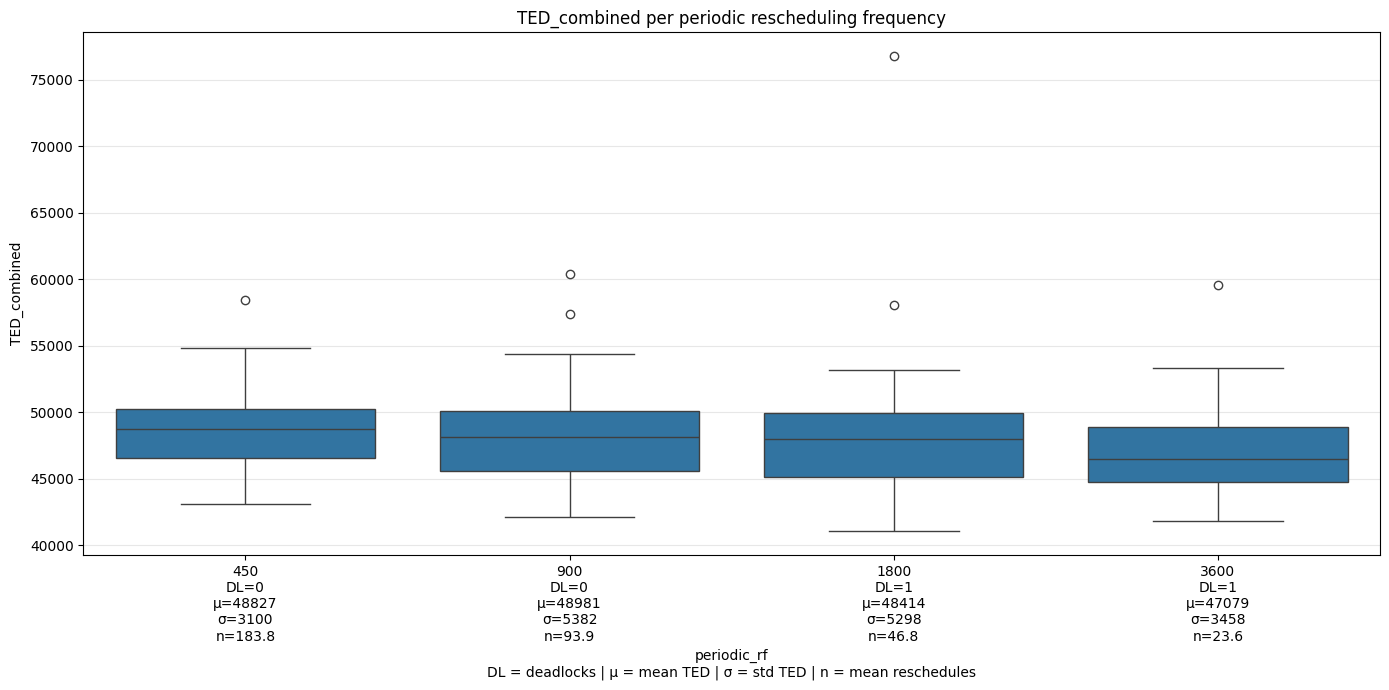

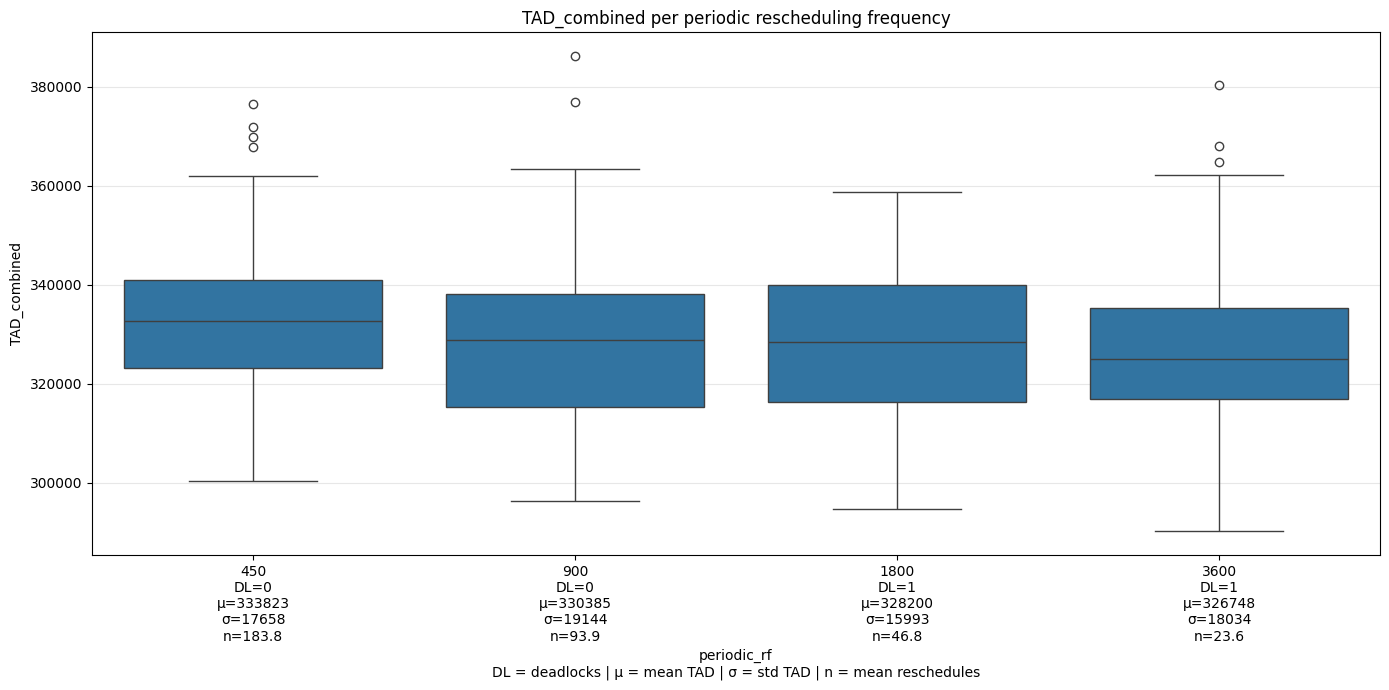

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# Filter periodic strategies
# ============================================================

periodic_df = raw_periodic.copy()

# Exclude baseline / no-rescheduling
periodic_df = periodic_df[periodic_df["periodic_rf"] != 100000]

# Sorteer periodic frequencies numeriek
freq_order = sorted(periodic_df["periodic_rf"].unique())

# ============================================================
# Statistieken per periodic_rf
# ============================================================

stats = (
    periodic_df
    .groupby("periodic_rf")
    .agg(
        deadlocks=("deadlock", "sum"),
        mean_TED=("TED_combined", "mean"),
        std_TED=("TED_combined", "std"),
        mean_TAD=("TAD_combined", "mean"),
        std_TAD=("TAD_combined", "std"),
        mean_reschedules=("n_rescheduled", "mean"),
    )
    .reindex(freq_order)
)

# Enkel feasible/non-deadlock runs voor de boxplots
plot_df = periodic_df[
    (~periodic_df["deadlock"]) &
    (~periodic_df["infeasible_run"])
].copy()

# ============================================================
# TED BOXPLOT
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

sns.boxplot(
    data=plot_df,
    x="periodic_rf",
    y="TED_combined",
    order=freq_order,
    ax=ax
)

# Stats onder x-as tonen
labels = []
for freq in freq_order:
    row = stats.loc[freq]

    label = (
        f"{freq}\n"
        f"DL={int(row['deadlocks'])}\n"
        f"μ={row['mean_TED']:.0f}\n"
        f"σ={row['std_TED']:.0f}\n"
        f"n={row['mean_reschedules']:.1f}"
    )

    labels.append(label)

ax.set_xticklabels(labels)

plt.title("TED_combined per periodic rescheduling frequency")
plt.xlabel(
    "periodic_rf\n"
    "DL = deadlocks | μ = mean TED | σ = std TED | n = mean reschedules"
)
plt.ylabel("TED_combined")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# TAD BOXPLOT
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

sns.boxplot(
    data=plot_df,
    x="periodic_rf",
    y="TAD_combined",
    order=freq_order,
    ax=ax
)

# Stats onder x-as tonen
labels = []
for freq in freq_order:
    row = stats.loc[freq]

    label = (
        f"{freq}\n"
        f"DL={int(row['deadlocks'])}\n"
        f"μ={row['mean_TAD']:.0f}\n"
        f"σ={row['std_TAD']:.0f}\n"
        f"n={row['mean_reschedules']:.1f}"
    )

    labels.append(label)

ax.set_xticklabels(labels)

plt.title("TAD_combined per periodic rescheduling frequency")
plt.xlabel(
    "periodic_rf\n"
    "DL = deadlocks | μ = mean TAD | σ = std TAD | n = mean reschedules"
)
plt.ylabel("TAD_combined")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#Event-Driven

In [14]:
raw_event = raw_all[(raw_all["strategy_type"] == "event_driven")]

In [15]:
raw_event.columns

Index(['seed', 'phase', 'strategy_type', 'periodic_rf', 'event_driven_rf',
       'controller_freq', 'threshold_conf', 'priority', 'weight_passenger',
       'weight_freight', 'gamma', 'upgrade', 'w_IC', 'w_L', 'w_S', 'w_EURST',
       'w_ICE', 'w_INT', 'w_freight', 'objective', 'freight_pct',
       'mc_delay_per_train', 'solver_timeout', 'total_solve_time',
       'n_rescheduled', 'n_fcfs_fallback', 'n_skipped', 'infeasible_run',
       'deadlock', 'TED_passenger', 'TED_freight', 'TED_combined',
       'TAD_passenger', 'TAD_freight', 'TAD_combined', 'delay_ratio',
       'n_passenger', 'n_freight', 'TED_IC', 'TED_L', 'TED_S', 'TED_EURST',
       'TED_ICE', 'TED_INT', 'n_IC', 'n_L', 'n_S', 'n_EURST', 'n_ICE', 'n_INT',
       'n_unfinished_IC', 'n_unfinished_L', 'n_unfinished_S',
       'n_unfinished_EURST', 'n_unfinished_ICE', 'n_unfinished_INT',
       'n_unfinished_freight', 'n_unfinished_total', 'config'],
      dtype='str')


Methodological note:
This analysis evaluates the effect of event-driven rescheduling frequency
while holding the controller frequency constant.

This conditional comparison is necessary because the experimental design
does not combine every event-driven frequency with every controller frequency.
Pooling all controller frequencies together would therefore introduce
confounding effects.

By fixing controller_freq = 900, differences in performance can be more
directly attributed to variations in event-driven rescheduling frequency.



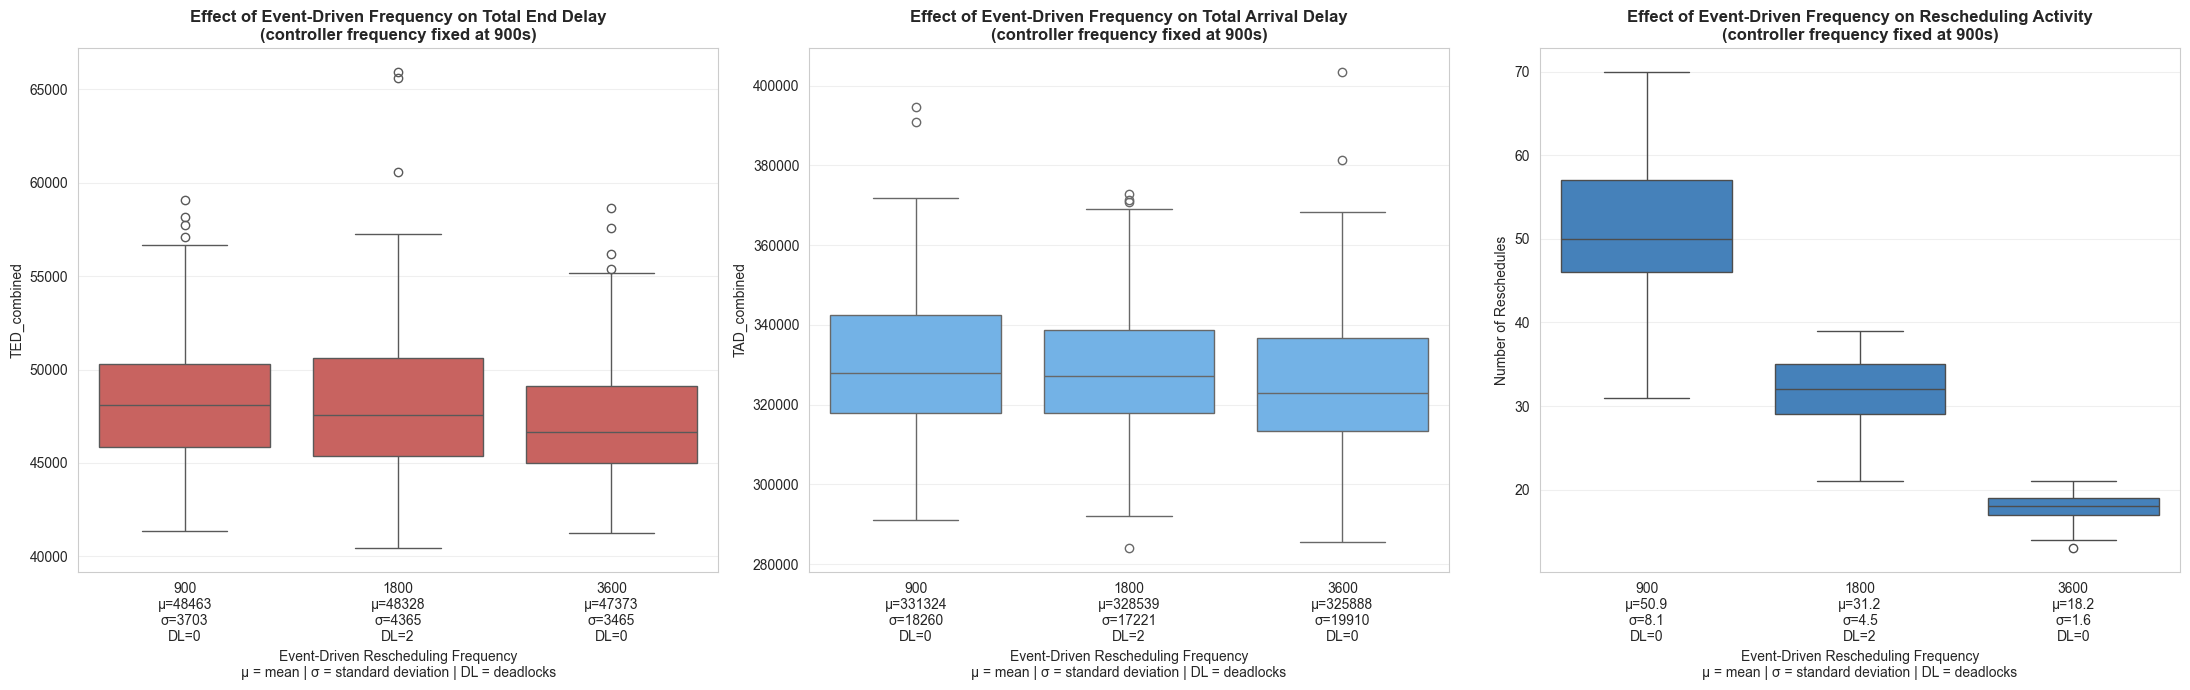

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# THESIS-STYLE COLOR PALETTE
# ============================================================

colors = {
    "IC": "#60B4F9",
    "L": "#90CDF4",
    "S": "#3182CE",
    "EURST": "#1E3A5F",
    "ICE": "#6A5ACD",
    "INT": "#2C5282",
    "Freight": "#D9534F"
}

# ============================================================
# METHODOLOGICAL NOTE
# ============================================================

print("""
Methodological note:
This analysis evaluates the effect of event-driven rescheduling frequency
while holding the controller frequency constant.

This conditional comparison is necessary because the experimental design
does not combine every event-driven frequency with every controller frequency.
Pooling all controller frequencies together would therefore introduce
confounding effects.

By fixing controller_freq = 900, differences in performance can be more
directly attributed to variations in event-driven rescheduling frequency.
""")

# ============================================================
# FILTER COMPARABLE CONFIGURATIONS
# ============================================================

df = raw_event.copy()

# Keep only configurations with controller_freq = 900
df = df[df["controller_freq"] == 900]

# Keep only overlapping / comparable event frequencies
valid_event_rf = [900, 1800, 3600]

df = df[df["event_driven_rf"].isin(valid_event_rf)]

# Remove deadlocks/infeasible runs from boxplots
plot_df = df[
    (~df["deadlock"]) &
    (~df["infeasible_run"])
].copy()

freq_order = sorted(valid_event_rf)

# ============================================================
# STATISTICS
# ============================================================

stats = (
    df.groupby("event_driven_rf")
    .agg(
        deadlocks=("deadlock", "sum"),

        mean_TED=("TED_combined", "mean"),
        std_TED=("TED_combined", "std"),

        mean_TAD=("TAD_combined", "mean"),
        std_TAD=("TAD_combined", "std"),

        mean_reschedules=("n_rescheduled", "mean"),
        std_reschedules=("n_rescheduled", "std"),
    )
    .reindex(freq_order)
)

# ============================================================
# PLOTTING
# ============================================================

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# ============================================================
# TED
# ============================================================

sns.boxplot(
    data=plot_df,
    x="event_driven_rf",
    y="TED_combined",
    order=freq_order,
    color=colors["Freight"],
    ax=axes[0]
)

labels = []

for freq in freq_order:
    row = stats.loc[freq]

    labels.append(
        f"{freq}\n"
        f"μ={row['mean_TED']:.0f}\n"
        f"σ={row['std_TED']:.0f}\n"
        f"DL={int(row['deadlocks'])}"
    )

axes[0].set_xticklabels(labels)

axes[0].set_title(
    "Effect of Event-Driven Frequency on Total End Delay\n"
    "(controller frequency fixed at 900s)",
    fontsize=12,
    fontweight="bold"
)

axes[0].set_xlabel(
    "Event-Driven Rescheduling Frequency\n"
    "μ = mean | σ = standard deviation | DL = deadlocks"
)

axes[0].set_ylabel("TED_combined")

# ============================================================
# TAD
# ============================================================

sns.boxplot(
    data=plot_df,
    x="event_driven_rf",
    y="TAD_combined",
    order=freq_order,
    color=colors["IC"],
    ax=axes[1]
)

labels = []

for freq in freq_order:
    row = stats.loc[freq]

    labels.append(
        f"{freq}\n"
        f"μ={row['mean_TAD']:.0f}\n"
        f"σ={row['std_TAD']:.0f}\n"
        f"DL={int(row['deadlocks'])}"
    )

axes[1].set_xticklabels(labels)

axes[1].set_title(
    "Effect of Event-Driven Frequency on Total Arrival Delay\n"
    "(controller frequency fixed at 900s)",
    fontsize=12,
    fontweight="bold"
)

axes[1].set_xlabel(
    "Event-Driven Rescheduling Frequency\n"
    "μ = mean | σ = standard deviation | DL = deadlocks"
)

axes[1].set_ylabel("TAD_combined")

# ============================================================
# RESCHEDULES
# ============================================================

sns.boxplot(
    data=plot_df,
    x="event_driven_rf",
    y="n_rescheduled",
    order=freq_order,
    color=colors["S"],
    ax=axes[2]
)

labels = []

for freq in freq_order:
    row = stats.loc[freq]

    labels.append(
        f"{freq}\n"
        f"μ={row['mean_reschedules']:.1f}\n"
        f"σ={row['std_reschedules']:.1f}\n"
        f"DL={int(row['deadlocks'])}"
    )

axes[2].set_xticklabels(labels)

axes[2].set_title(
    "Effect of Event-Driven Frequency on Rescheduling Activity\n"
    "(controller frequency fixed at 900s)",
    fontsize=12,
    fontweight="bold"
)

axes[2].set_xlabel(
    "Event-Driven Rescheduling Frequency\n"
    "μ = mean | σ = standard deviation | DL = deadlocks"
)

axes[2].set_ylabel("Number of Reschedules")

# ============================================================
# GLOBAL FORMATTING
# ============================================================

for ax in axes:
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

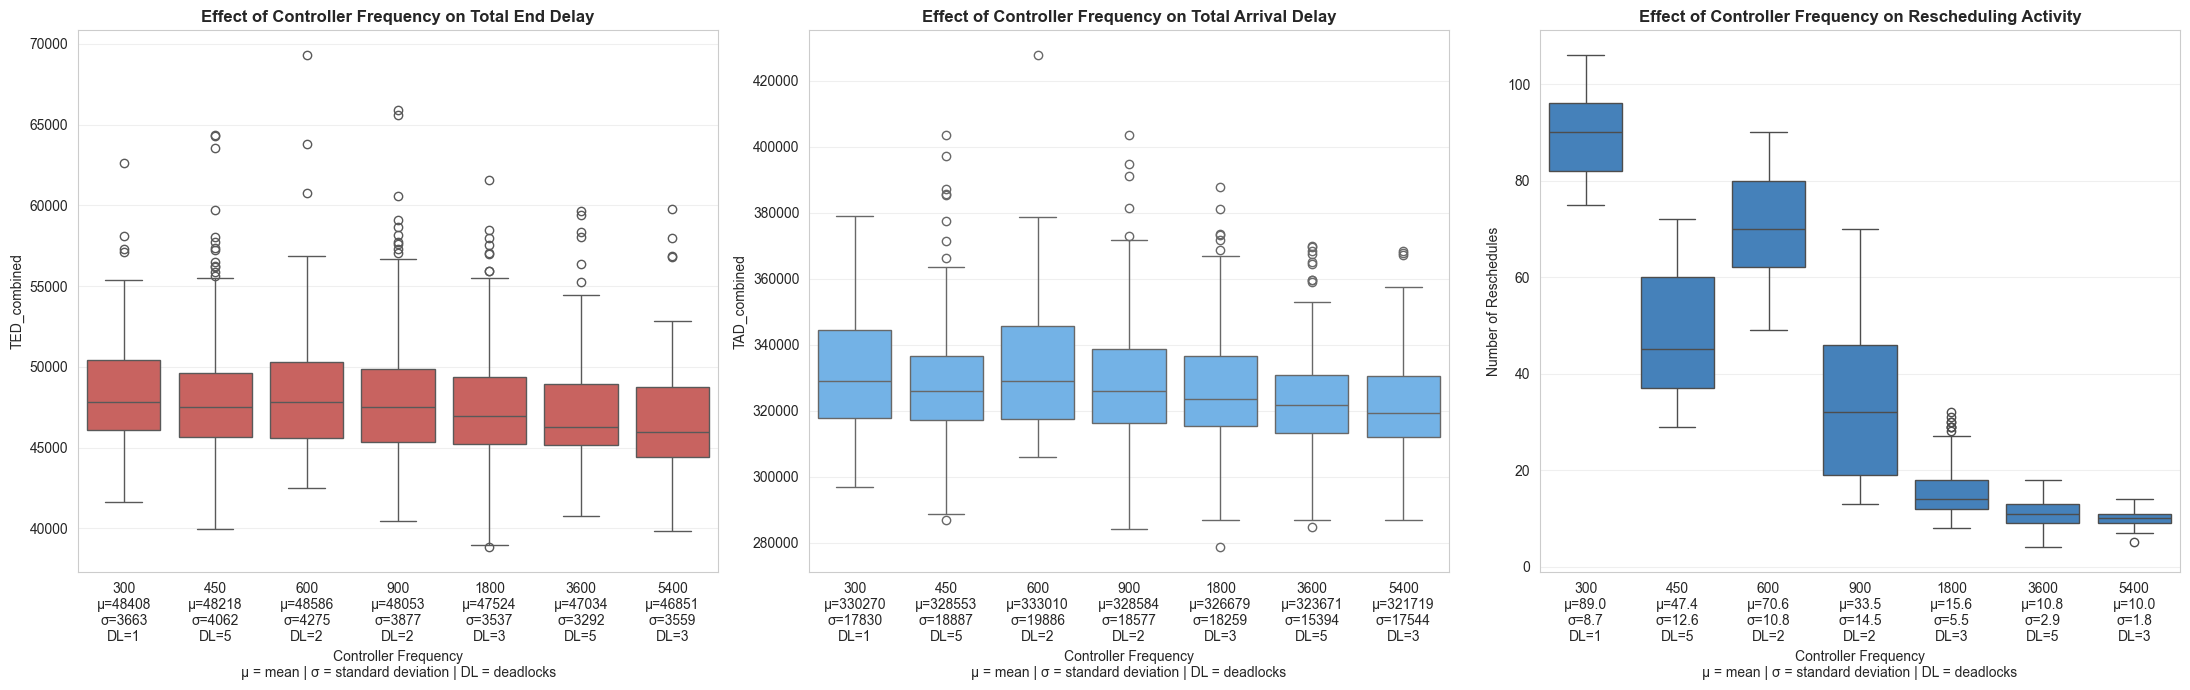


Methodological note:
This analysis evaluates the effect of controller frequency
while holding the event-driven rescheduling frequency constant.

This conditional comparison is necessary because the experimental
design does not combine every controller frequency with every
event-driven frequency.

Pooling all event-driven frequencies together would therefore
introduce confounding effects.

By fixing event_driven_rf = 1800, differences in performance
can be more directly attributed to variations in controller frequency.



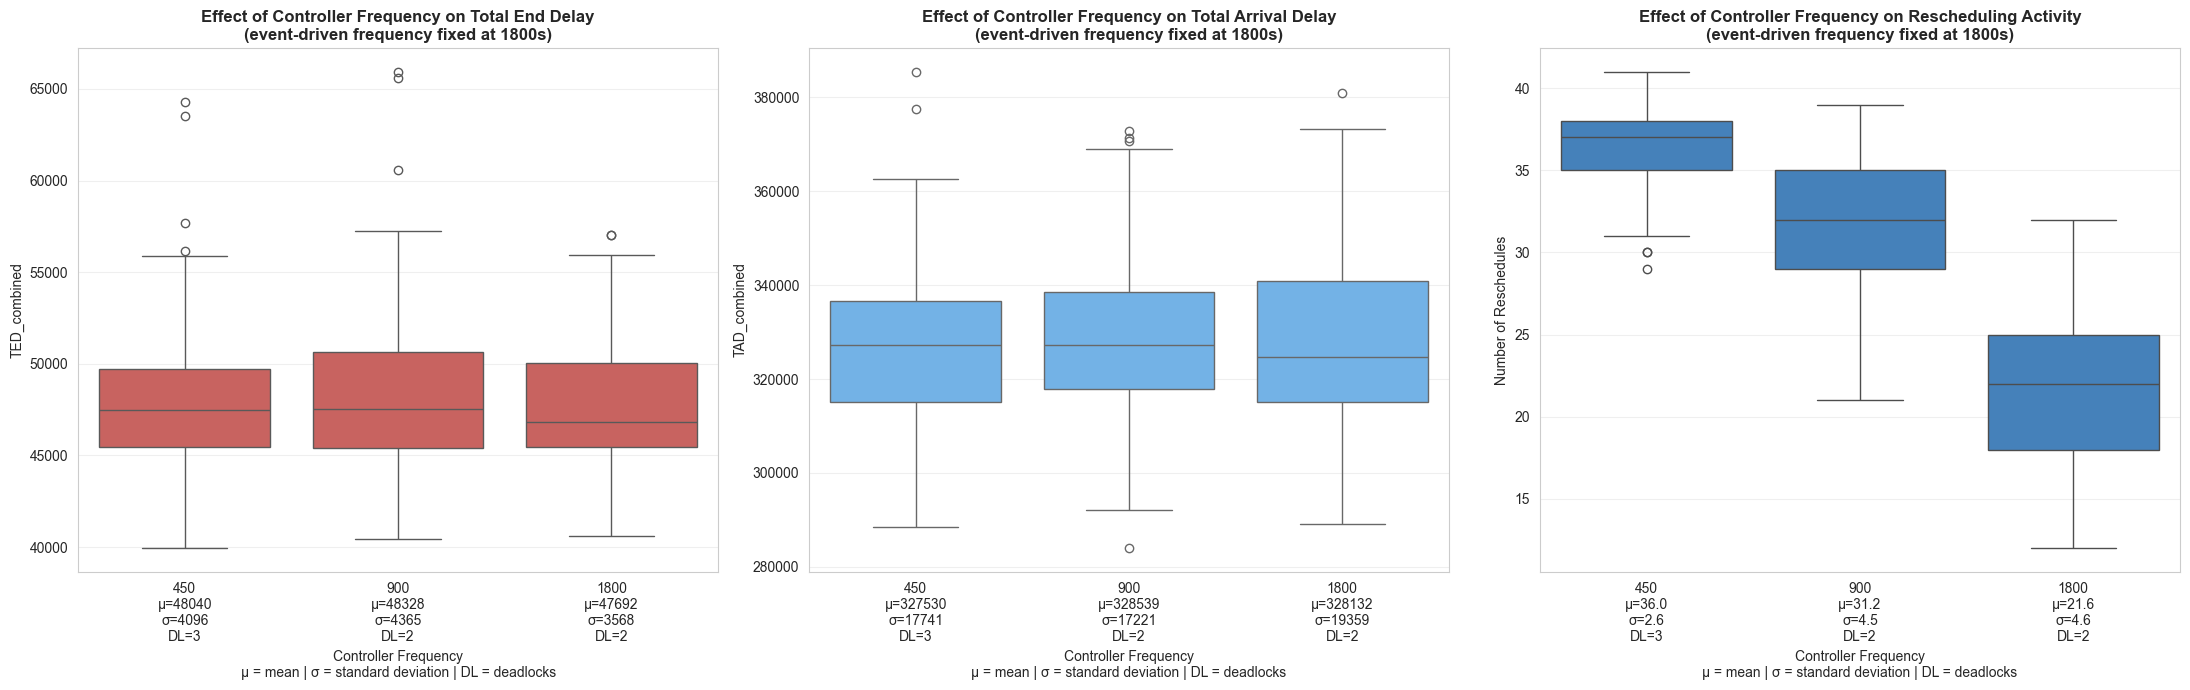

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# THESIS-STYLE COLOR PALETTE
# ============================================================

colors = {
    "IC": "#60B4F9",
    "L": "#90CDF4",
    "S": "#3182CE",
    "EURST": "#1E3A5F",
    "ICE": "#6A5ACD",
    "INT": "#2C5282",
    "Freight": "#D9534F"
}

# ============================================================
# METHODOLOGICAL NOTE
# ============================================================

print("""
Methodological note:
This analysis evaluates the effect of controller frequency
while holding the event-driven rescheduling frequency constant.

This conditional comparison is necessary because the experimental
design does not combine every controller frequency with every
event-driven frequency.

Pooling all event-driven frequencies together would therefore
introduce confounding effects.

By fixing event_driven_rf = 1800, differences in performance
can be more directly attributed to variations in controller frequency.
""")

# ============================================================
# FILTER COMPARABLE CONFIGURATIONS
# ============================================================

df = raw_event.copy()

# Fix event-driven frequency
df = df[df["event_driven_rf"] == 1800]

# Keep only overlapping / comparable controller frequencies
valid_controller_freqs = [450, 900, 1800]

df = df[df["controller_freq"].isin(valid_controller_freqs)]

# Remove deadlocks/infeasible runs from boxplots
plot_df = df[
    (~df["deadlock"]) &
    (~df["infeasible_run"])
].copy()

freq_order = sorted(valid_controller_freqs)

# ============================================================
# STATISTICS
# ============================================================

stats = (
    df.groupby("controller_freq")
    .agg(
        deadlocks=("deadlock", "sum"),

        mean_TED=("TED_combined", "mean"),
        std_TED=("TED_combined", "std"),

        mean_TAD=("TAD_combined", "mean"),
        std_TAD=("TAD_combined", "std"),

        mean_reschedules=("n_rescheduled", "mean"),
        std_reschedules=("n_rescheduled", "std"),
    )
    .reindex(freq_order)
)

# ============================================================
# PLOTTING STYLE
# ============================================================

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# ============================================================
# TED
# ============================================================

sns.boxplot(
    data=plot_df,
    x="controller_freq",
    y="TED_combined",
    order=freq_order,
    color=colors["Freight"],
    ax=axes[0]
)

labels = []

for freq in freq_order:
    row = stats.loc[freq]

    labels.append(
        f"{freq}\n"
        f"μ={row['mean_TED']:.0f}\n"
        f"σ={row['std_TED']:.0f}\n"
        f"DL={int(row['deadlocks'])}"
    )

axes[0].set_xticklabels(labels)

axes[0].set_title(
    "Effect of Controller Frequency on Total End Delay\n"
    "(event-driven frequency fixed at 1800s)",
    fontsize=12,
    fontweight="bold"
)

axes[0].set_xlabel(
    "Controller Frequency\n"
    "μ = mean | σ = standard deviation | DL = deadlocks"
)

axes[0].set_ylabel("TED_combined")

# ============================================================
# TAD
# ============================================================

sns.boxplot(
    data=plot_df,
    x="controller_freq",
    y="TAD_combined",
    order=freq_order,
    color=colors["IC"],
    ax=axes[1]
)

labels = []

for freq in freq_order:
    row = stats.loc[freq]

    labels.append(
        f"{freq}\n"
        f"μ={row['mean_TAD']:.0f}\n"
        f"σ={row['std_TAD']:.0f}\n"
        f"DL={int(row['deadlocks'])}"
    )

axes[1].set_xticklabels(labels)

axes[1].set_title(
    "Effect of Controller Frequency on Total Arrival Delay\n"
    "(event-driven frequency fixed at 1800s)",
    fontsize=12,
    fontweight="bold"
)

axes[1].set_xlabel(
    "Controller Frequency\n"
    "μ = mean | σ = standard deviation | DL = deadlocks"
)

axes[1].set_ylabel("TAD_combined")

# ============================================================
# RESCHEDULES
# ============================================================

sns.boxplot(
    data=plot_df,
    x="controller_freq",
    y="n_rescheduled",
    order=freq_order,
    color=colors["S"],
    ax=axes[2]
)

labels = []

for freq in freq_order:
    row = stats.loc[freq]

    labels.append(
        f"{freq}\n"
        f"μ={row['mean_reschedules']:.1f}\n"
        f"σ={row['std_reschedules']:.1f}\n"
        f"DL={int(row['deadlocks'])}"
    )

axes[2].set_xticklabels(labels)

axes[2].set_title(
    "Effect of Controller Frequency on Rescheduling Activity\n"
    "(event-driven frequency fixed at 1800s)",
    fontsize=12,
    fontweight="bold"
)

axes[2].set_xlabel(
    "Controller Frequency\n"
    "μ = mean | σ = standard deviation | DL = deadlocks"
)

axes[2].set_ylabel("Number of Reschedules")

# ============================================================
# GLOBAL FORMATTING
# ============================================================

for ax in axes:
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


Methodological note:
Unlike event-driven and controller frequencies, threshold confidence
was evaluated across all event-driven configurations.

Since threshold_conf acts as a trigger sensitivity parameter rather than
a structural timing parameter, pooling across configurations is considered
acceptable for exploratory analysis.

The resulting trends should therefore be interpreted as global behavioural
effects of trigger aggressiveness.



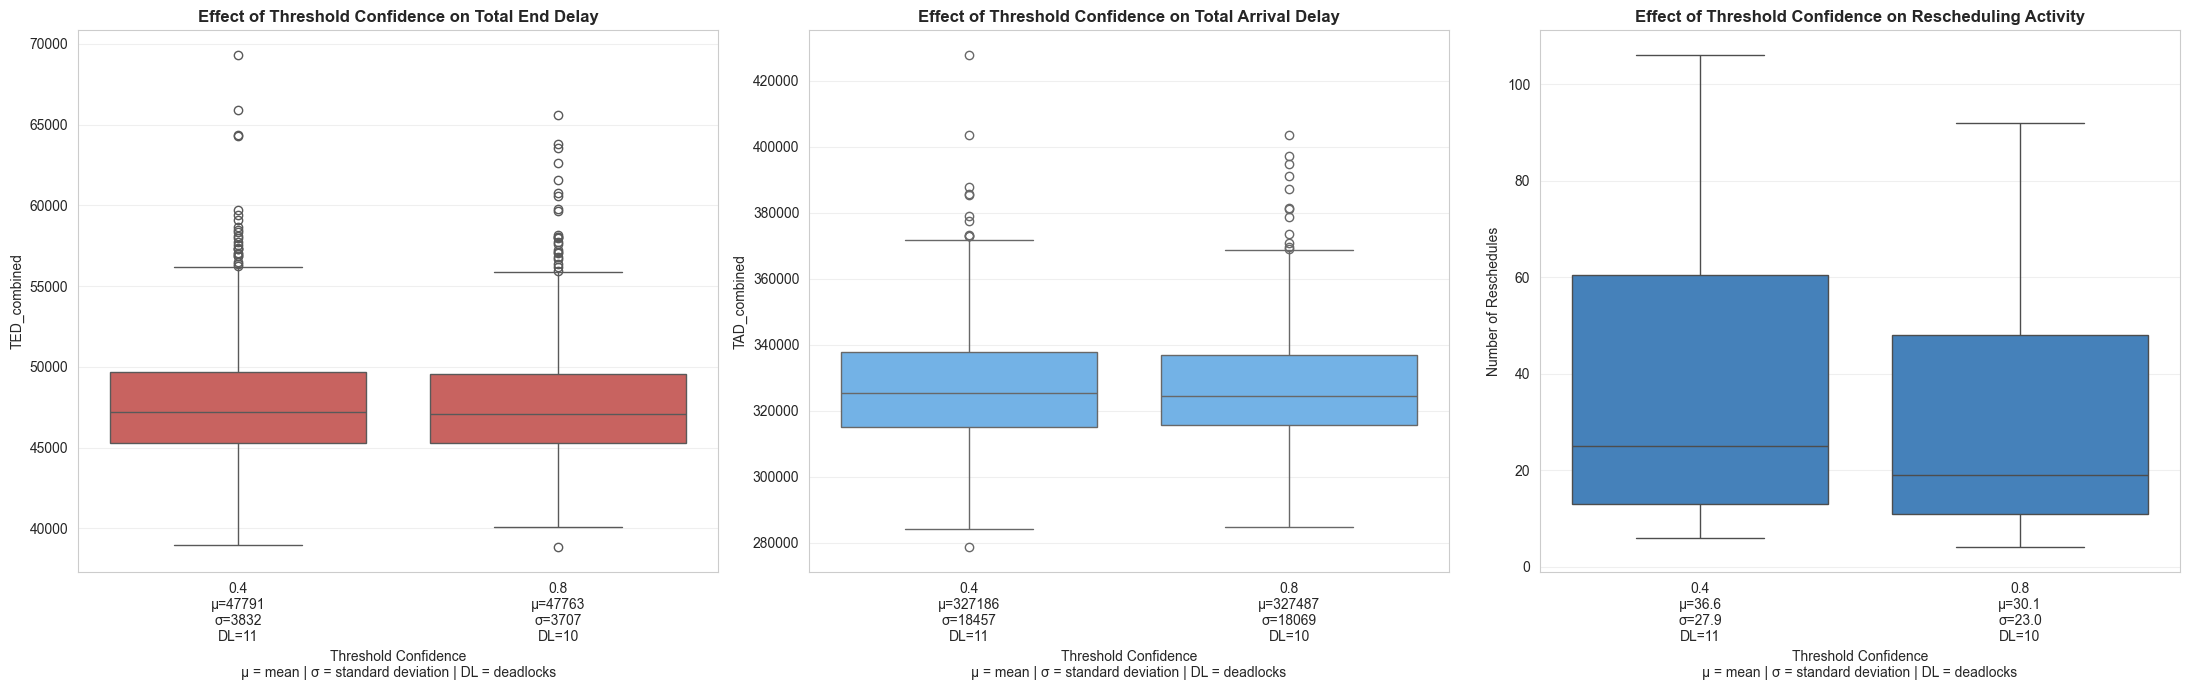

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# THESIS-STYLE COLOR PALETTE
# ============================================================

colors = {
    "IC": "#60B4F9",
    "L": "#90CDF4",
    "S": "#3182CE",
    "EURST": "#1E3A5F",
    "ICE": "#6A5ACD",
    "INT": "#2C5282",
    "Freight": "#D9534F"
}

# ============================================================
# METHODOLOGICAL NOTE
# ============================================================

print("""
Methodological note:
Unlike event-driven and controller frequencies, threshold confidence
was evaluated across all event-driven configurations.

Since threshold_conf acts as a trigger sensitivity parameter rather than
a structural timing parameter, pooling across configurations is considered
acceptable for exploratory analysis.

The resulting trends should therefore be interpreted as global behavioural
effects of trigger aggressiveness.
""")

# ============================================================
# FILTER EVENT-DRIVEN STRATEGIES
# ============================================================

df = raw_event.copy()

# Remove deadlocks/infeasible runs from boxplots
plot_df = df[
    (~df["deadlock"]) &
    (~df["infeasible_run"])
].copy()

# Sort threshold values
threshold_order = sorted(plot_df["threshold_conf"].unique())

# ============================================================
# STATISTICS
# ============================================================

stats = (
    df.groupby("threshold_conf")
    .agg(
        deadlocks=("deadlock", "sum"),

        mean_TED=("TED_combined", "mean"),
        std_TED=("TED_combined", "std"),

        mean_TAD=("TAD_combined", "mean"),
        std_TAD=("TAD_combined", "std"),

        mean_reschedules=("n_rescheduled", "mean"),
        std_reschedules=("n_rescheduled", "std"),
    )
    .reindex(threshold_order)
)

# ============================================================
# PLOTTING STYLE
# ============================================================

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# ============================================================
# TED
# ============================================================

sns.boxplot(
    data=plot_df,
    x="threshold_conf",
    y="TED_combined",
    order=threshold_order,
    color=colors["Freight"],
    ax=axes[0]
)

labels = []

for conf in threshold_order:
    row = stats.loc[conf]

    labels.append(
        f"{conf}\n"
        f"μ={row['mean_TED']:.0f}\n"
        f"σ={row['std_TED']:.0f}\n"
        f"DL={int(row['deadlocks'])}"
    )

axes[0].set_xticklabels(labels)

axes[0].set_title(
    "Effect of Threshold Confidence on Total End Delay",
    fontsize=12,
    fontweight="bold"
)

axes[0].set_xlabel(
    "Threshold Confidence\n"
    "μ = mean | σ = standard deviation | DL = deadlocks"
)

axes[0].set_ylabel("TED_combined")

# ============================================================
# TAD
# ============================================================

sns.boxplot(
    data=plot_df,
    x="threshold_conf",
    y="TAD_combined",
    order=threshold_order,
    color=colors["IC"],
    ax=axes[1]
)

labels = []

for conf in threshold_order:
    row = stats.loc[conf]

    labels.append(
        f"{conf}\n"
        f"μ={row['mean_TAD']:.0f}\n"
        f"σ={row['std_TAD']:.0f}\n"
        f"DL={int(row['deadlocks'])}"
    )

axes[1].set_xticklabels(labels)

axes[1].set_title(
    "Effect of Threshold Confidence on Total Arrival Delay",
    fontsize=12,
    fontweight="bold"
)

axes[1].set_xlabel(
    "Threshold Confidence\n"
    "μ = mean | σ = standard deviation | DL = deadlocks"
)

axes[1].set_ylabel("TAD_combined")

# ============================================================
# RESCHEDULES
# ============================================================

sns.boxplot(
    data=plot_df,
    x="threshold_conf",
    y="n_rescheduled",
    order=threshold_order,
    color=colors["S"],
    ax=axes[2]
)

labels = []

for conf in threshold_order:
    row = stats.loc[conf]

    labels.append(
        f"{conf}\n"
        f"μ={row['mean_reschedules']:.1f}\n"
        f"σ={row['std_reschedules']:.1f}\n"
        f"DL={int(row['deadlocks'])}"
    )

axes[2].set_xticklabels(labels)

axes[2].set_title(
    "Effect of Threshold Confidence on Rescheduling Activity",
    fontsize=12,
    fontweight="bold"
)

axes[2].set_xlabel(
    "Threshold Confidence\n"
    "μ = mean | σ = standard deviation | DL = deadlocks"
)

axes[2].set_ylabel("Number of Reschedules")

# ============================================================
# GLOBAL FORMATTING
# ============================================================

for ax in axes:
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

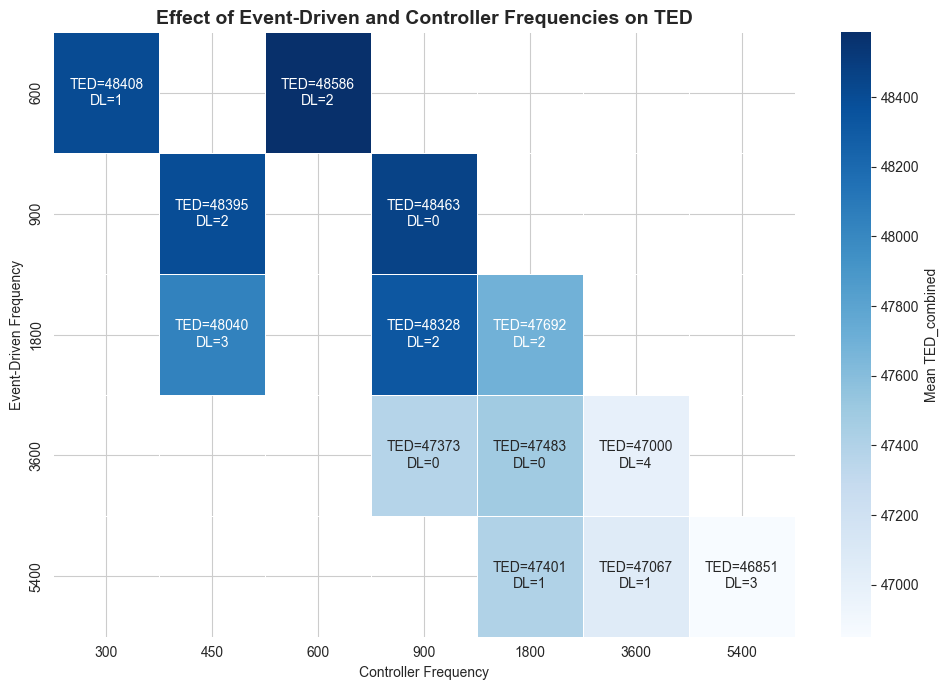

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# THESIS-STYLE COLOR PALETTE
# ============================================================

colors = {
    "IC": "#60B4F9",
    "L": "#90CDF4",
    "S": "#3182CE",
    "EURST": "#1E3A5F",
    "ICE": "#6A5ACD",
    "INT": "#2C5282",
    "Freight": "#D9534F"
}

# ============================================================
# PREPARE DATA
# ============================================================

df = raw_event.copy()

# Exclude infeasible/deadlocks for TED analysis
plot_df = df[
    (~df["deadlock"]) &
    (~df["infeasible_run"])
].copy()

# ============================================================
# AGGREGATE MEAN TED
# ============================================================

heatmap_data = (
    plot_df
    .groupby(["event_driven_rf", "controller_freq"])["TED_combined"]
    .mean()
    .reset_index()
)

# Pivot for heatmap
pivot_ted = heatmap_data.pivot(
    index="event_driven_rf",
    columns="controller_freq",
    values="TED_combined"
)

# ============================================================
# DEADLOCK COUNTS
# ============================================================

deadlocks = (
    df.groupby(["event_driven_rf", "controller_freq"])["deadlock"]
    .sum()
    .reset_index()
)

pivot_dl = deadlocks.pivot(
    index="event_driven_rf",
    columns="controller_freq",
    values="deadlock"
)

# ============================================================
# BUILD ANNOTATIONS
# ============================================================

annotations = pivot_ted.copy().astype(str)

for i in pivot_ted.index:
    for j in pivot_ted.columns:

        ted = pivot_ted.loc[i, j]
        dl  = pivot_dl.loc[i, j]

        if pd.isna(ted):
            annotations.loc[i, j] = ""
        else:
            annotations.loc[i, j] = (
                f"TED={ted:.0f}\n"
                f"DL={int(dl)}"
            )

# ============================================================
# PLOT HEATMAP
# ============================================================

plt.figure(figsize=(10, 7))

sns.heatmap(
    pivot_ted,
    annot=annotations,
    fmt="",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Mean TED_combined"}
)

plt.title(
    "Effect of Event-Driven and Controller Frequencies on TED",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Controller Frequency")
plt.ylabel("Event-Driven Frequency")

plt.tight_layout()
plt.show()

### Hybrid


In [28]:
raw_hybrid = raw_all[(raw_all["strategy_type"] == "hybrid")]

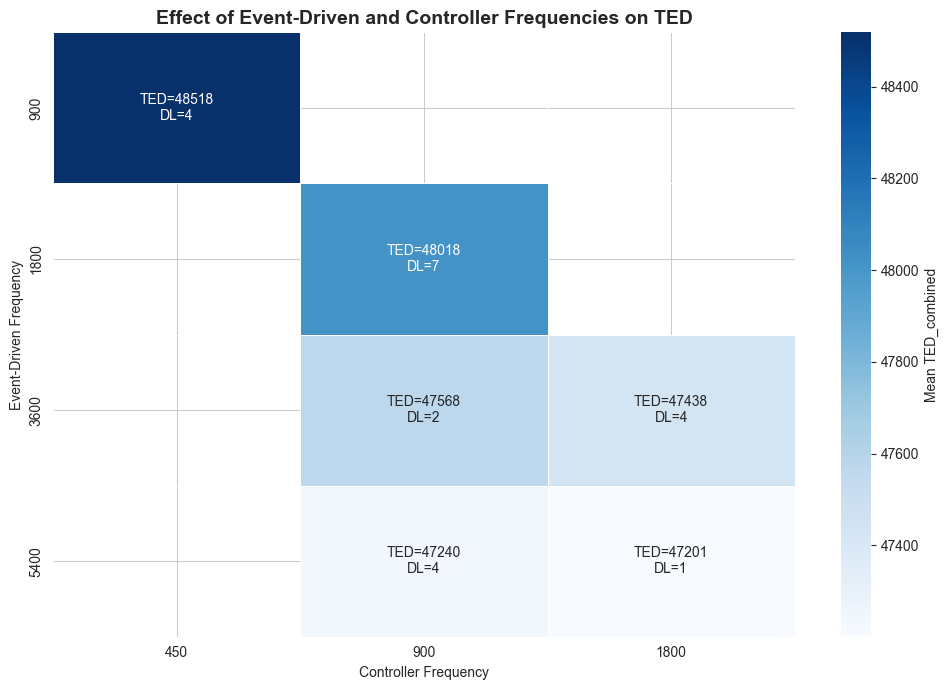

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# THESIS-STYLE COLOR PALETTE
# ============================================================

colors = {
    "IC": "#60B4F9",
    "L": "#90CDF4",
    "S": "#3182CE",
    "EURST": "#1E3A5F",
    "ICE": "#6A5ACD",
    "INT": "#2C5282",
    "Freight": "#D9534F"
}

# ============================================================
# PREPARE DATA
# ============================================================

df = raw_hybrid.copy()

# Exclude infeasible/deadlocks for TED analysis
plot_df = df[
    (~df["deadlock"]) &
    (~df["infeasible_run"])
].copy()

# ============================================================
# AGGREGATE MEAN TED
# ============================================================

heatmap_data = (
    plot_df
    .groupby(["event_driven_rf", "controller_freq"])["TED_combined"]
    .mean()
    .reset_index()
)

# Pivot for heatmap
pivot_ted = heatmap_data.pivot(
    index="event_driven_rf",
    columns="controller_freq",
    values="TED_combined"
)

# ============================================================
# DEADLOCK COUNTS
# ============================================================

deadlocks = (
    df.groupby(["event_driven_rf", "controller_freq"])["deadlock"]
    .sum()
    .reset_index()
)

pivot_dl = deadlocks.pivot(
    index="event_driven_rf",
    columns="controller_freq",
    values="deadlock"
)

# ============================================================
# BUILD ANNOTATIONS
# ============================================================

annotations = pivot_ted.copy().astype(str)

for i in pivot_ted.index:
    for j in pivot_ted.columns:

        ted = pivot_ted.loc[i, j]
        dl  = pivot_dl.loc[i, j]

        if pd.isna(ted):
            annotations.loc[i, j] = ""
        else:
            annotations.loc[i, j] = (
                f"TED={ted:.0f}\n"
                f"DL={int(dl)}"
            )

# ============================================================
# PLOT HEATMAP
# ============================================================

plt.figure(figsize=(10, 7))

sns.heatmap(
    pivot_ted,
    annot=annotations,
    fmt="",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Mean TED_combined"}
)

plt.title(
    "Effect of Event-Driven and Controller Frequencies on TED",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Controller Frequency")
plt.ylabel("Event-Driven Frequency")

plt.tight_layout()
plt.show()